In [ ]:
import requests
import os
import random
import shutil
import gzip
from pyteomics import mgf
import matplotlib.pyplot as plt
import numpy as np
from pyteomics import fasta, parser, mass
import pandas as pd

In [38]:

url = "https://www.ebi.ac.uk/pride/ws/archive/v2/projects/PXD000045/files"
response = requests.get(url)
files = response.json()

for f in files:
    name = f.get("fileName", "")
    size = round(f.get("fileSize", 0) / 1e6, 1)
    category = f.get("fileCategory", {}).get("value", "")
    print(f"{name} | {size} MB | {category}")

PRIDE_Exp_Complete_Ac_27370.pride.mztab.gz | 0.0 MB | OTHER
PRIDE_Exp_Complete_Ac_27370.pride.mgf.gz | 0.0 MB | PEAK
CZCV24421G11101XMS.RAW.ZIP | 0.0 MB | RAW
CZCV24021G11101XMS.RAW.ZIP | 0.0 MB | RAW
CZCV23621G11101XMS.RAW.ZIP | 0.0 MB | RAW
CZCV22821G11101XMS.RAW.ZIP | 0.0 MB | RAW
CZCV20821G11101XMS.RAW.ZIP | 0.0 MB | RAW
CZCV23021G11101XMS.RAW.ZIP | 0.0 MB | RAW
F014737.dat | 0.0 MB | SEARCH
CZCV23821G11101XMS.RAW.ZIP | 0.0 MB | RAW
CZCV21821G11101XMS.RAW.ZIP | 0.0 MB | RAW
PRIDE_Exp_Complete_Ac_27370.xml.gz | 0.0 MB | RESULT
CZCV24221G11101XMS.RAW.ZIP | 0.0 MB | RAW
CZCV22221G11101XMS.RAW.ZIP | 0.0 MB | RAW
F014735.dat | 0.0 MB | SEARCH
CZCV21621G11101XMS.RAW.ZIP | 0.0 MB | RAW
CZCV23421G11101XMS.RAW.ZIP | 0.0 MB | RAW
CZCV22021G11101XMS.RAW.ZIP | 0.0 MB | RAW
F014734.dat | 0.0 MB | SEARCH
CZCV22421G11101XMS.RAW.ZIP | 0.0 MB | RAW
CZCV22621G11101XMS.RAW.ZIP | 0.0 MB | RAW
F014738.dat | 0.0 MB | SEARCH
CZCV21021G11101XMS.RAW.ZIP | 0.0 MB | RAW
F014736.dat | 0.0 MB | SEARCH
CZCV2142

In [40]:
for f in files:
    name = f.get("fileName", "")
    if "mgf" in name.lower():
        print("File:", name)
        print("Locations:", f.get("publicFileLocations"))

File: PRIDE_Exp_Complete_Ac_27370.pride.mgf.gz
Locations: [{'@type': 'CvParam', 'cvLabel': 'PRIDE', 'accession': 'PRIDE:0000468', 'name': 'Aspera Protocol', 'value': 'prd_ascp@fasp.ebi.ac.uk:pride/data/archive/2013/06/PXD000045/generated/PRIDE_Exp_Complete_Ac_27370.pride.mgf.gz'}, {'@type': 'CvParam', 'cvLabel': 'PRIDE', 'accession': 'PRIDE:0000469', 'name': 'FTP Protocol', 'value': 'ftp://ftp.pride.ebi.ac.uk/pride/data/archive/2013/06/PXD000045/generated/PRIDE_Exp_Complete_Ac_27370.pride.mgf.gz'}]


In [44]:
ftp_url = "https://ftp.pride.ebi.ac.uk/pride/data/archive/2013/06/PXD000045/generated/PRIDE_Exp_Complete_Ac_27370.pride.mgf.gz"

output_path = r"C:\Users\za945\OneDrive\Desktop\proteomics_project\data\sample.mgf.gz"

print("Downloading...")
response = requests.get(ftp_url, stream=True)

with open(output_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("Done! File size:", round(os.path.getsize(output_path) / 1e6, 1), "MB")

Downloading...
Done! File size: 61.4 MB


In [49]:
mgf_gz_path = r"C:\Users\za945\OneDrive\Desktop\proteomics_project\data\sample.mgf.gz"
mgf_path = r"C:\Users\za945\OneDrive\Desktop\proteomics_project\data\sample.mgf"

with gzip.open(mgf_gz_path, "rb") as f_in:
    with open(mgf_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Unzipped! File size:", round(os.path.getsize(mgf_path) / 1e6, 1), "MB")

Unzipped! File size: 158.1 MB


In [50]:
with mgf.read(mgf_path) as reader:
    for i, spectrum in enumerate(reader):
        print(f"--- Spectrum {i+1} ---")
        print("m/z values:", spectrum["m/z array"][:5])
        print("intensities:", spectrum["intensity array"][:5])
        print("params:", spectrum["params"])
        if i >= 2:
            break

--- Spectrum 1 ---
m/z values: [303.614 444.405 337.471 243.237 628.606]
intensities: [ 9.7 13.8 17.2 11.3 13. ]
params: {'title': 'id=PXD000045;PRIDE_Exp_Complete_Ac_27370.xml;spectrum=1', 'pepmass': (400.261938, None), 'charge': [2]}
--- Spectrum 2 ---
m/z values: [180.13  645.362 379.472 603.248 631.188]
intensities: [ 13.8 307.1  80.7   9.   28.7]
params: {'title': 'id=PXD000045;PRIDE_Exp_Complete_Ac_27370.xml;spectrum=2', 'pepmass': (401.725588, None), 'charge': [2]}
--- Spectrum 3 ---
m/z values: [370.544 206.944 251.032 428.336 392.549]
intensities: [ 15.6   7.5 111.6  13.5 257.1]
params: {'title': 'id=PXD000045;PRIDE_Exp_Complete_Ac_27370.xml;spectrum=3', 'pepmass': (401.733138, None), 'charge': [2]}


Total spectra: 17968


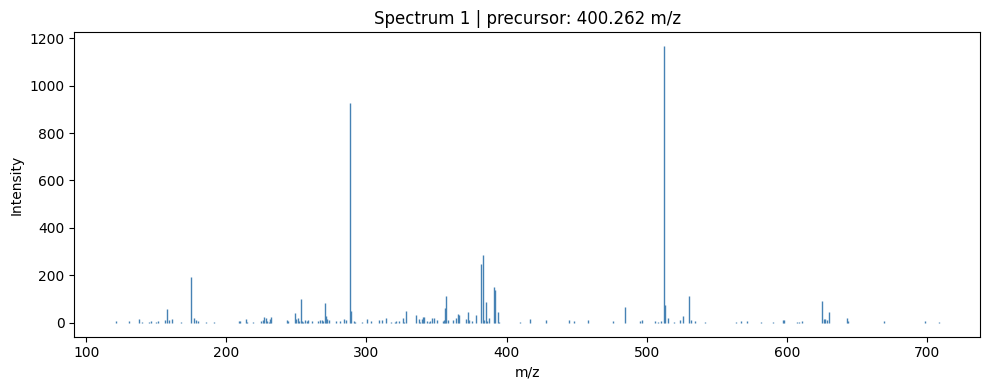

In [53]:
with mgf.read(mgf_path) as reader:
    spectra = list(reader)

print(f"Total spectra: {len(spectra)}")

# Plot first spectrum
spectrum = spectra[0]
mz = spectrum["m/z array"]
intensity = spectrum["intensity array"]

plt.figure(figsize=(10, 4))
plt.vlines(mz, 0, intensity, color="steelblue", linewidth=1)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title(f"Spectrum 1 | precursor: {spectrum['params']['pepmass'][0]:.3f} m/z")
plt.tight_layout()
plt.show()

       precursor_mz    charge  num_peaks  max_intensity  total_intensity
count      17968.00  17968.00   17968.00       17968.00         17968.00
mean         756.16      2.14     576.54        4092.43         39718.17
std          214.04      0.36     273.11       12748.68         69829.84
min          400.26      1.00      27.00          26.80           268.10
25%          593.85      2.00     381.00         811.28         11535.65
50%          714.89      2.00     542.00        1792.00         22120.00
75%          891.52      2.00     717.00        3954.00         46181.38
max         1573.84      5.00    1915.00      790600.00       3302714.00


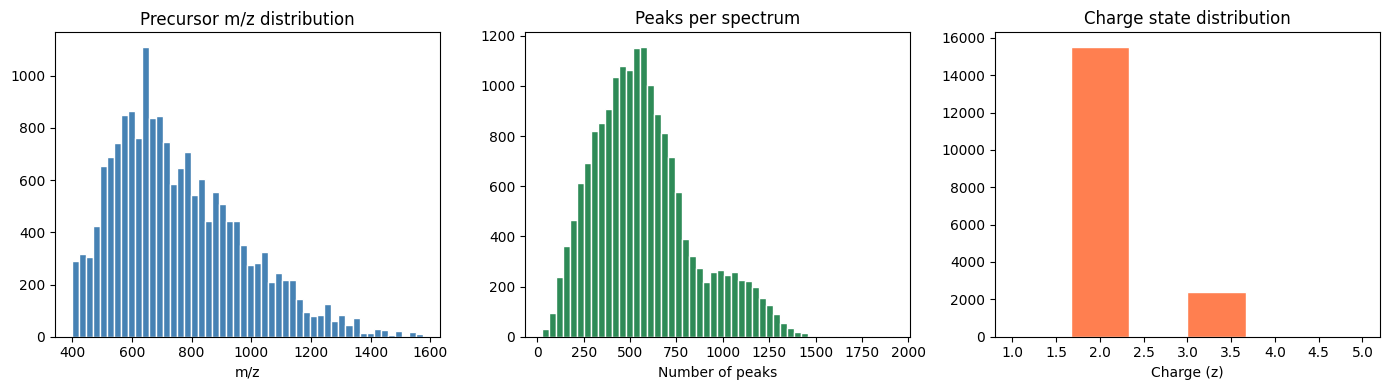

In [55]:


# Build a summary dataframe
summary = []
for s in spectra:
    summary.append({
        "precursor_mz": s["params"]["pepmass"][0],
        "charge": s["params"].get("charge", [0])[0],
        "num_peaks": len(s["m/z array"]),
        "max_intensity": s["intensity array"].max(),
        "total_intensity": s["intensity array"].sum(),
    })

df = pd.DataFrame(summary)
print(df.describe().round(2))

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["precursor_mz"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Precursor m/z distribution")
axes[0].set_xlabel("m/z")

axes[1].hist(df["num_peaks"], bins=50, color="seagreen", edgecolor="white")
axes[1].set_title("Peaks per spectrum")
axes[1].set_xlabel("Number of peaks")

axes[2].hist(df["charge"].astype(int), bins=6, color="coral", edgecolor="white")
axes[2].set_title("Charge state distribution")
axes[2].set_xlabel("Charge (z)")

plt.tight_layout()
plt.show()

In [56]:
def filter_spectrum(mz_array, intensity_array, min_intensity_pct=1.0, min_peaks=10):
    """
    Remove noise peaks:
    - Keep only peaks above min_intensity_pct% of max intensity
    - Discard spectra with fewer than min_peaks after filtering
    """
    max_int = intensity_array.max()
    threshold = max_int * (min_intensity_pct / 100)
    
    mask = intensity_array >= threshold
    filtered_mz = mz_array[mask]
    filtered_int = intensity_array[mask]
    
    if len(filtered_mz) < min_peaks:
        return None, None
    
    return filtered_mz, filtered_int

# Apply to all spectra
filtered_spectra = []
discarded = 0

for s in spectra:
    mz, intensity = filter_spectrum(s["m/z array"], s["intensity array"])
    if mz is not None:
        filtered_spectra.append({
            "params": s["params"],
            "m/z array": mz,
            "intensity array": intensity
        })
    else:
        discarded += 1

print(f"Original spectra:  {len(spectra)}")
print(f"Filtered spectra:  {len(filtered_spectra)}")
print(f"Discarded:         {discarded}")

Original spectra:  17968
Filtered spectra:  17966
Discarded:         2


In [57]:
# Download Mycobacterium tuberculosis H37Rv proteome from UniProt
url = "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=proteome:UP000001584"
output = r"C:\Users\za945\OneDrive\Desktop\proteomics_project\data\mtb.fasta"

print("Downloading MTB proteome...")
response = requests.get(url, stream=True)

with open(output, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("Done! Size:", round(os.path.getsize(output) / 1e6, 1), "MB")

Done! Size: 1.9 MB


In [ ]:

fasta_path = r"C:\Users\za945\OneDrive\Desktop\proteomics_project\data\mtb.fasta"

proteins = list(fasta.read(fasta_path))

print(f"Total proteins: {len(proteins)}")
print("\nFirst 3 proteins:")
for p in proteins[:3]:
    print("ID:", p.description[:80])
    print("Length:", len(p.sequence), "aa")
    print("---")

Total proteins: 3997

First 3 proteins:
ID: sp|A0A089QRB9|MSL3_MYCTU Mycolipanoate synthase OS=Mycobacterium tuberculosis (s
Length: 2085 aa
---
ID: sp|I6WXK4|PTPB_MYCTU Triple specificity protein phosphatase PtpB OS=Mycobacteriu
Length: 276 aa
---
ID: sp|I6WZG6|ENCAP_MYCTU Type 1 encapsulin shell protein OS=Mycobacterium tuberculo
Length: 265 aa
---


In [ ]:

# Digest all proteins with trypsin
print("Digesting proteins...")

peptide_db = {}  # peptide sequence -> protein ID

for protein in proteins:
    protein_id = protein.description.split("|")[1] if "|" in protein.description else protein.description[:20]
    
    # Trypsin digestion (cleave after K, R)
    peptides = parser.cleave(
        protein.sequence,
        parser.expasy_rules["trypsin"],
        missed_cleavages=1,
        min_length=7,
        max_length=30
    )
    
    for pep in peptides:
        if pep not in peptide_db:
            peptide_db[pep] = []
        peptide_db[pep].append(protein_id)

print(f"Total unique peptides: {len(peptide_db)}")

Digesting proteins...
Total unique peptides: 129753


In [ ]:

print("Calculating peptide masses...")

# Calculate theoretical mass for each peptide
peptide_masses = {}

for pep in peptide_db:
    try:
        m = mass.calculate_mass(sequence=pep)
        peptide_masses[pep] = m
    except:
        continue

print(f"Peptides with calculated mass: {len(peptide_masses)}")

# Show a few examples
for pep, m in list(peptide_masses.items())[:5]:
    print(f"{pep} -> {m:.4f} Da -> proteins: {peptide_db[pep]}")

Calculating peptide masses...
Peptides with calculated mass: 129753
VVLDVPR -> 796.4807 Da -> proteins: ['A0A089QRB9']
SVSRWGAFLDDVGGFDCDFFGLTER -> 2795.2650 Da -> proteins: ['A0A089QRB9']
IHNVAAFPGAAYCEMALAAAR -> 2146.0452 Da -> proteins: ['A0A089QRB9']
LRNYHSTR -> 1045.5417 Da -> proteins: ['A0A089QRB9']
LPDQLAEIDTELFVPQANTSWPDNTGQPRR -> 3407.6746 Da -> proteins: ['A0A089QRB9']


In [61]:
print("Matching spectra to peptides...")

tolerance_ppm = 10  # 10 ppm mass tolerance
results = []

for i, s in enumerate(filtered_spectra[:1000]):  # test with first 1000
    precursor_mz = s["params"]["pepmass"][0]
    charge = s["params"].get("charge", [2])[0]
    
    # Calculate neutral mass from m/z
    neutral_mass = (precursor_mz * charge) - (charge * 1.00728)
    
    # Search against peptide database
    best_match = None
    best_error = float("inf")
    
    for pep, theo_mass in peptide_masses.items():
        error_ppm = abs(neutral_mass - theo_mass) / theo_mass * 1e6
        if error_ppm < tolerance_ppm and error_ppm < best_error:
            best_error = error_ppm
            best_match = pep
    
    if best_match:
        results.append({
            "spectrum_id": i,
            "precursor_mz": precursor_mz,
            "charge": charge,
            "peptide": best_match,
            "protein": peptide_db[best_match][0],
            "error_ppm": round(best_error, 3)
        })

df_results = pd.DataFrame(results)
print(f"Matched: {len(df_results)} / 1000 spectra")
print(df_results.head(10))


Matching spectra to peptides...
Matched: 996 / 1000 spectra
   spectrum_id  precursor_mz  charge  peptide protein  error_ppm
0            0    400.261938       2  QALKIAR  P9WQF7      2.184
1            1    401.725588       2  ISNFPPK  L7N648      2.337
2            2    401.733138       2  MAPLSRK  P96419      1.719
3            3    402.232488       2  MLRANAK  P9WGZ9      2.584
4            4    403.719938       2  WAVGAFR  P9WK07      2.245
5            5    403.719938       2  WAVGAFR  P9WK07      2.245
6            6    406.723188       2  TQVATHR  P9WJU9      2.177
7            7    406.747138       2  VQPVLEK  P9WIS5      0.786
8            8    407.743738       2  ALVQVER  I6XD69      2.537
9            9    408.190288       2  TYSTGMR  P72047      2.060


In [62]:
print("Running full database search...")

results_all = []

for i, s in enumerate(filtered_spectra):
    precursor_mz = s["params"]["pepmass"][0]
    charge = s["params"].get("charge", [2])[0]
    neutral_mass = (precursor_mz * charge) - (charge * 1.00728)
    
    best_match = None
    best_error = float("inf")
    
    for pep, theo_mass in peptide_masses.items():
        error_ppm = abs(neutral_mass - theo_mass) / theo_mass * 1e6
        if error_ppm < 10 and error_ppm < best_error:
            best_error = error_ppm
            best_match = pep
    
    if best_match:
        results_all.append({
            "spectrum_id": i,
            "precursor_mz": precursor_mz,
            "charge": charge,
            "peptide": best_match,
            "protein": peptide_db[best_match][0],
            "error_ppm": round(best_error, 3)
        })
    
    if i % 1000 == 0:
        print(f"  Progress: {i}/{len(filtered_spectra)}")

df_all = pd.DataFrame(results_all)
print(f"\nTotal matched: {len(df_all)} / {len(filtered_spectra)}")



Running full database search...
  Progress: 0/17966
  Progress: 1000/17966
  Progress: 2000/17966
  Progress: 3000/17966
  Progress: 4000/17966
  Progress: 5000/17966
  Progress: 6000/17966
  Progress: 7000/17966
  Progress: 8000/17966
  Progress: 9000/17966
  Progress: 10000/17966
  Progress: 11000/17966
  Progress: 12000/17966
  Progress: 13000/17966
  Progress: 14000/17966
  Progress: 15000/17966
  Progress: 16000/17966
  Progress: 17000/17966

Total matched: 17722 / 17966


NameError: name 'output_' is not defined

In [63]:
# Save results
output_path = r"C:\Users\za945\OneDrive\Desktop\proteomics_project\results\search_results.csv"
df_all.to_csv(output_path, index=False)
print("Saved to search_results.csv")

Saved to search_results.csv


In [64]:
import pickle

with open(r"C:\Users\za945\OneDrive\Desktop\proteomics_project\data\spectra.pkl", "wb") as f:
    pickle.dump(filtered_spectra, f)

with open(r"C:\Users\za945\OneDrive\Desktop\proteomics_project\data\peptide_db.pkl", "wb") as f:
    pickle.dump(peptide_db, f)

with open(r"C:\Users\za945\OneDrive\Desktop\proteomics_project\data\peptide_masses.pkl", "wb") as f:
    pickle.dump(peptide_masses, f)

df_all.to_csv(r"C:\Users\za945\OneDrive\Desktop\proteomics_project\results\search_results.csv", index=False)

print("All saved!")

All saved!
